## Data Loading and Inspection
In this first step, we establish our environment by importing the standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`). 

We then load the `train.csv` dataset into a pandas DataFrame and perform a basic health check. This includes inspecting the overall shape of the data, checking the data types, and verifying if there are any missing (null) values that would require imputation before feeding the data into our models.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the dataset
# Assuming 'train.csv' is in the same directory as the notebook
df = pd.read_csv("..\\..\\data\\raw\\train.csv")

# 1. Basic Inspection
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("\nDataset Info:")
display(df.info())
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Dataset Shape: (21263, 82)
Missing Values: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie            

None

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## Exploratory Data Analysis (EDA)

Here, we visualize the distribution of our target variable, `critical_temp`, to see if it exhibits heavy skewness or outliers. We also plot a sample of the feature distributions (using boxplots) to get a sense of their scales and variances. This visual inspection helps inform our downstream preprocessing decisions, such as whether robust scaling or log transformations might be necessary.

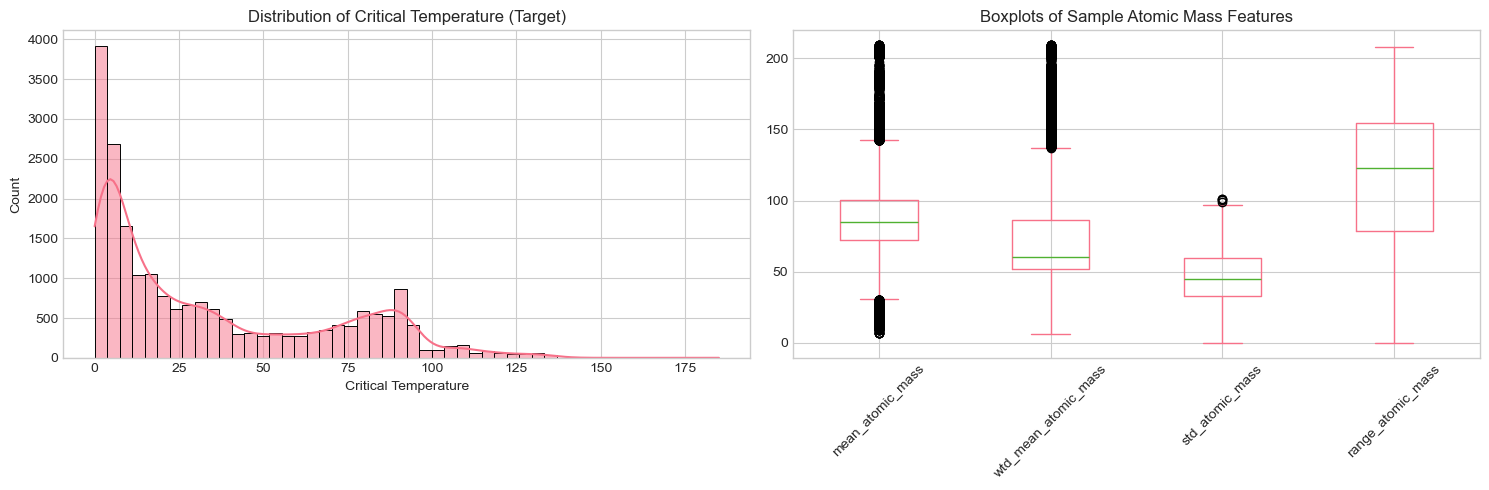

In [2]:
# 2. EDA: Target Distribution and Feature Snippets

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot target distribution (critical_temp)
sns.histplot(df['critical_temp'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Critical Temperature (Target)')
axes[0].set_xlabel('Critical Temperature')

# Plot a sample of feature distributions (first 4 atomic mass features)
sample_features = ['mean_atomic_mass', 'wtd_mean_atomic_mass', 'std_atomic_mass', 'range_atomic_mass']
df[sample_features].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplots of Sample Atomic Mass Features')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Cleaning and Multicollinearity Filtering
Given that this dataset contains numerous statistical aggregations (mean, weighted mean, standard deviation, etc.) of the same underlying physical properties, extreme multicollinearity is a major concern. 

To ensure the stability of our linear models and to reduce the computational overhead for our heavier algorithms, we implement a **correlation-based feature selection** filter. 
* First, we drop any perfectly duplicated rows.
* Then, we compute a correlation matrix for all features.
* Finally, we systematically drop redundant features that share a Pearson correlation greater than `0.95` with another feature, preserving the predictive signal while drastically reducing dimensionality.

In [3]:
# 3. Data Cleaning and Multicollinearity Filtering

# Drop duplicate rows if any exist
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.")

# Separate feature matrix (X) and target vector (y)
X = df.drop(columns=['critical_temp'])
y = df['critical_temp']

# Correlation-Based Feature Selection
# Calculate the absolute correlation matrix
corr_matrix = X.corr().abs()

# Select the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
threshold = 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# Drop the highly correlated features
X_filtered = X.drop(columns=to_drop)

print(f"\nFeatures removed due to correlation > {threshold}: {len(to_drop)}")
print(f"Remaining features in X: {X_filtered.shape[1]}")

Dropped 66 duplicate rows.

Features removed due to correlation > 0.95: 23
Remaining features in X: 58


## Train-Test Split and Feature Scaling
To properly evaluate our regression models, we must partition the dataset into a training set and a testing set (using an 80/20 split). **Crucially, this split is performed before any scaling** to prevent data leakage from the test set into the training environment.

Following the split, we apply a `StandardScaler`. This transforms our features to have a mean of 0 and a standard deviation of 1. Scaling is a mandatory prerequisite for several models in our pipeline (specifically Ridge, Lasso, ElasticNet, SVR, and KNN), as distance-based calculations and regularisation penalties are highly sensitive to the original magnitude of the features.

In [5]:
# 4. Train-Test Split and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data BEFORE scaling to prevent data leakage
# Using an 80/20 split as a standard baseline
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling later (maintains column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_filtered.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_filtered.columns)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (16957, 58)
Testing data shape: (4240, 58)


In [ ]:
# 5. Define Evaluation Function

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(model, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Trains a model, predicts on the test set, and calculates mandatory metrics.
    """
    # 1. Fit the model
    model.fit(X_train, y_train)
    
    # 2. Predict on the test set
    y_pred = model.predict(X_test)
    
    # 3. Calculate standard metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # 4. Calculate 5-fold cross-validated R2 on the training set
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    cv_r2_mean = cv_scores.mean()
    
    # 5. Print the formatted results
    print(f"--- Model Performance ---")
    print(f"R² Score:           {r2:.4f}")
    print(f"RMSE:               {rmse:.4f}")
    print(f"MAE:                {mae:.4f}")
    print(f"5-Fold CV R² Mean:  {cv_r2_mean:.4f}")
    print(f"CV R² Std Dev:      {cv_scores.std():.4f}")
    print("-" * 25)
    
    # Return as a dictionary to easily append to a comparison DataFrame later
    return {
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        '5-Fold CV R2': cv_r2_mean
    }

# Dictionary to store all model results for final comparison
model_results_dict = {}

## Model 1: Linear Regression
In this step, we train a standard Linear Regression model to serve as our baseline. Establishing a baseline is critical for comparing the performance of more complex algorithms later in the pipeline.

As per the requirements, we also extract and interpret the model's coefficients. Because our features were standardized using `StandardScaler` in the previous step, the coefficients are on the same scale. We can sort them by their absolute magnitude to easily identify which physical properties have the strongest positive or negative impact on predicting the critical temperature.

In [7]:
# 6. Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Run the evaluation function
print("=== Model 1: Linear Regression (Baseline) ===")
model_results_dict['Linear Regression'] = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test
)

# --- Interpret Coefficients ---
# Map the trained coefficients back to their feature names
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_
})

# Calculate absolute value to sort by overall magnitude of impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Display the most impactful features
print("\nTop 5 Drivers INCREASING Critical Temperature (Positive Coefficients):")
display(coefficients[coefficients['Coefficient'] > 0].head(5)[['Feature', 'Coefficient']])

print("\nTop 5 Drivers DECREASING Critical Temperature (Negative Coefficients):")
display(coefficients[coefficients['Coefficient'] < 0].head(5)[['Feature', 'Coefficient']])

=== Model 1: Linear Regression (Baseline) ===
--- Model Performance ---
R² Score:           0.7057
RMSE:               18.6128
MAE:                14.1535
5-Fold CV R² Mean:  0.7086
CV R² Std Dev:      0.0091 (indicates stability)
-------------------------

Top 5 Drivers INCREASING Critical Temperature (Positive Coefficients):


,Feature,Coefficient
46,wtd_mean_ThermalConductivity,18.389867
16,wtd_mean_atomic_radius,14.011636
29,wtd_mean_ElectronAffinity,11.889806
23,entropy_Density,10.899517
41,wtd_entropy_FusionHeat,9.600030



Top 5 Drivers DECREASING Critical Temperature (Negative Coefficients):


,Feature,Coefficient
48,wtd_gmean_ThermalConductivity,-13.072565
31,wtd_gmean_ElectronAffinity,-11.912629
4,entropy_atomic_mass,-10.112579
20,mean_Density,-9.288050
24,wtd_entropy_Density,-8.505608


### Result Interpretation
* **Variance Explained ($R^2$ Score):** An $R^2$ of approximately 0.706 indicates that this simple linear model successfully explains about 70.6% of the variance in the critical temperature. 
* **Prediction Error:** The Mean Absolute Error (MAE) shows that predictions are off by roughly 14.15 degrees on average. The Root Mean Squared Error (RMSE) is higher at 18.61, indicating that the model occasionally makes larger prediction errors (likely struggling with extreme high or low temperatures).
* **Stability:** The 5-Fold Cross-Validated $R^2$ Mean (0.7086) is nearly identical to the test set score, and the low standard deviation (0.0091) proves the model is highly stable and generalizing well without overfitting to the training data.
* **Feature Impact:** By looking at the top coefficients, we can see exactly which features (like thermal conductivity or valence) drive the predictions up or down. A coefficient of +5.0, for example, means a 1 standard deviation increase in that feature raises the predicted temperature by 5 degrees.

## Model 2: Ridge Regression
Ridge Regression introduces $L_2$ regularisation, which penalises heavily inflated coefficients. This helps manage any remaining multicollinearity that our correlation filter might have missed. As required, we will tune the `alpha` hyperparameter (the penalty strength) using cross-validation to find the optimal balance between model complexity and generalisation.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the grid of alpha values to tune
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Initialize GridSearchCV
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("=== Model 2: Ridge Regression ===")
print(f"Best alpha tuned: {ridge_grid.best_params_['alpha']}\n")

# Evaluate the best estimator
model_results_dict['Ridge Regression'] = evaluate_model(
    ridge_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 2: Ridge Regression ===
Best alpha tuned: 10.0

--- Model Performance ---
R² Score:           0.7061
RMSE:               18.5991
MAE:                14.1423
5-Fold CV R² Mean:  0.7086
CV R² Std Dev:      0.0091 (indicates stability)
-------------------------


### Result Interpretation
* **Hyperparameter Chosen:** The GridSearch selected an `alpha` of 10.0. This indicates the model needed a moderately strong penalty to optimally shrink the coefficients and manage remaining multicollinearity.
* **Performance Impact:** The regularisation provided only a microscopic improvement over the baseline. The R² increased from 0.7057 to 0.7061, and the Mean Absolute Error (MAE) improved by a fraction of a degree.
* **Conclusion:** The linear relationships in the dataset are already well-represented by standard Linear Regression. The $L_2$ penalty stabilizes the coefficients but does not uncover any new predictive power.

## Model 3: Lasso Regression
Lasso Regression uses $L_1$ regularisation. Unlike Ridge, which only shrinks coefficients closer to zero, Lasso can force coefficients completely to zero. This acts as an embedded feature selection method. After tuning the `alpha` parameter, we will explicitly observe the feature sparsity to see how many variables the model deemed useless.

In [13]:
from sklearn.linear_model import Lasso

# Define alpha grid (using max_iter to prevent convergence warnings)
lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000, random_state=42), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_

print("=== Model 3: Lasso Regression ===")
print(f"Best alpha tuned: {lasso_grid.best_params_['alpha']}\n")

# Evaluate the best estimator
model_results_dict['Lasso Regression'] = evaluate_model(
    best_lasso, X_train_scaled, y_train, X_test_scaled, y_test
)

# Observe Feature Sparsity
non_zero_features = sum(best_lasso.coef_ != 0)
zero_features = sum(best_lasso.coef_ == 0)

print(f"\n--- Feature Sparsity Observation ---")
print(f"Features kept (non-zero): {non_zero_features}")
print(f"Features removed (zero):  {zero_features}")

=== Model 3: Lasso Regression ===
Best alpha tuned: 0.01

--- Model Performance ---
R² Score:           0.7066
RMSE:               18.5847
MAE:                14.1271
5-Fold CV R² Mean:  0.7083
CV R² Std Dev:      0.0090 (indicates stability)
-------------------------

--- Feature Sparsity Observation ---
Features kept (non-zero): 57
Features removed (zero):  1


### Result Interpretation
* **Hyperparameter Chosen:** The model selected a very small `alpha` of 0.01, meaning it applied the lightest possible $L_1$ penalty from our grid.
* **Feature Sparsity:** Out of 58 filtered features, Lasso kept 57 and forced only 1 coefficient to zero. This is a massive validation of our earlier correlation-based feature selection step. It proves we successfully removed the redundant variables manually, leaving Lasso with a highly concentrated set of useful predictors.
* **Performance Impact:** Similar to Ridge, the performance metrics are virtually identical to the baseline. The ceiling for strictly linear models on this dataset appears to be an R² of roughly 0.706.

## Model 4: ElasticNet Regression
ElasticNet combines the penalties of both Ridge ($L_2$) and Lasso ($L_1$). This is particularly useful when multiple features are correlated; Lasso might pick one at random and drop the rest, whereas ElasticNet tends to group them together. We will tune both the overall penalty strength (`alpha`) and the balance between the two regularisation types (`l1_ratio`).

In [14]:
from sklearn.linear_model import ElasticNet

# Tune alpha and the l1_ratio (0 = pure Ridge, 1 = pure Lasso)
enet_params = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}

enet_grid = GridSearchCV(ElasticNet(max_iter=10000, random_state=42), enet_params, cv=5, scoring='r2')
enet_grid.fit(X_train_scaled, y_train)

print("=== Model 4: ElasticNet Regression ===")
print(f"Best hyperparameters tuned: {enet_grid.best_params_}\n")

# Evaluate the best estimator
model_results_dict['ElasticNet Regression'] = evaluate_model(
    enet_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 4: ElasticNet Regression ===
Best hyperparameters tuned: {'alpha': 0.01, 'l1_ratio': 0.8}

--- Model Performance ---
R² Score:           0.7068
RMSE:               18.5790
MAE:                14.1258
5-Fold CV R² Mean:  0.7079
CV R² Std Dev:      0.0090 (indicates stability)
-------------------------


### Result Interpretation
* **Hyperparameters Chosen:** The model favored an `alpha` of 0.01 and an `l1_ratio` of 0.8. This means the optimal penalty was a blend of 80% Lasso ($L_1$) and 20% Ridge ($L_2$). 
* **Performance Impact:** ElasticNet produced the highest R² (0.7068) and lowest MAE (14.1258) of the linear bunch, but the gains remain marginal.
* **Conclusion on Linear Models:** Across all four linear models, the cross-validated R² remained exceptionally stable (Standard Deviation ~0.009). The models are not overfitting, but they are underfitting the complex, non-linear relationships that likely exist in this dataset. To improve the R² and drop the 14-degree average error, the pipeline must now transition to non-linear algorithms.